In [2]:
import numpy as np
import tensorflow as tf
import random

np.random.seed(42)
tf.random.set_seed(42)
random.seed(42)

In [3]:
#import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from tensorflow.keras.models import load_model
from sklearn.metrics.pairwise import cosine_similarity

In [7]:
import pandas as pd
from tensorflow.keras.models import load_model
import joblib

#load file yang dibutuhkan
# Load dataset
df = pd.read_csv('/content/processed_data (1).csv')

# List kategori IT yang ingin kita pertahankan (sesuaikan dengan data kamumu)
it_categories = ['Data Science', 'Database', 'DevOps', 'Java Developer', 'Python Developer', 'SQL Developer', 'Testing']

# Membuang baris data yang bukan termasuk IT
df = df[df['category'].isin(it_categories)].reset_index(drop=True)

# Load model
model = load_model('/content/tech_hire_model_final (3).keras')

# Load vectorizer
vectorizer = joblib.load('/content/tfidf_vectorizer_final (3).pkl')

# Load label encoder
label_encoder = joblib.load('/content/label_encoder_final (3).pkl')

# Lihat data
df.head()

,cv_text,job_desc,category,cv_clean,job_clean
0,jessica claire montgomery street san francisco...,SUMMARY\nTHE SR. HR GENERALIST PROVIDES HR EXP...,Java Developer,jessica claire montgomery street san francisco...,summary sr hr generalist provides hr expertise...
1,jared arthur maica java developer 17994568777 ...,BE PART OF A STELLAR TEAM AT YSB AS THE MANAGE...,Java Developer,jared arthur maica java developer linkedincomi...,part stellar team ysb manager human resource j...
2,jessica claire 9 resumesampleexamplecom 555 43...,OUR CLIENT IS A THRIVING ORGANIZATION OFFERING...,Java Developer,jessica claire resumesampleexamplecom montgome...,client thriving organization offering unique o...
3,jessica claire 9 resumesampleexamplecom 555 43...,JOB TITLE: CHIEF HUMAN RESOURCES OFFICER (CHRO...,Java Developer,jessica claire resumesampleexamplecom montgome...,job title chief human resource officer chroind...
4,jessica claire 100 montgomery st 10th floor xx...,DESCRIPTION\n\n WHO WE ARE \n\nAVI-SPL IS A DI...,Java Developer,jessica claire montgomery st th floor xxx resu...,description avispl digital enablement solution...


In [10]:
temp_df = pd.read_csv('/content/processed_data (1).csv')
print("Columns in processed_data.csv:")
print(temp_df.columns)
display(temp_df.head())

Columns in processed_data.csv:
Index(['cv_text', 'job_desc', 'category', 'cv_clean', 'job_clean'], dtype='object')


,cv_text,job_desc,category,cv_clean,job_clean
0,jessica claire montgomery street san francisco...,SUMMARY\nTHE SR. HR GENERALIST PROVIDES HR EXP...,Java Developer,jessica claire montgomery street san francisco...,summary sr hr generalist provides hr expertise...
1,jared arthur maica java developer 17994568777 ...,BE PART OF A STELLAR TEAM AT YSB AS THE MANAGE...,Java Developer,jared arthur maica java developer linkedincomi...,part stellar team ysb manager human resource j...
2,jessica claire 9 resumesampleexamplecom 555 43...,OUR CLIENT IS A THRIVING ORGANIZATION OFFERING...,Java Developer,jessica claire resumesampleexamplecom montgome...,client thriving organization offering unique o...
3,jessica claire 9 resumesampleexamplecom 555 43...,JOB TITLE: CHIEF HUMAN RESOURCES OFFICER (CHRO...,Java Developer,jessica claire resumesampleexamplecom montgome...,job title chief human resource officer chroind...
4,jessica claire 100 montgomery st 10th floor xx...,DESCRIPTION\n\n WHO WE ARE \n\nAVI-SPL IS A DI...,Java Developer,jessica claire montgomery st th floor xxx resu...,description avispl digital enablement solution...


In [11]:
#pengecekkkan nama kolom dataset
print(df.columns)

Index(['cv_text', 'job_desc', 'category', 'cv_clean', 'job_clean'], dtype='object')


In [12]:
cv_column = 'cv_clean'
jd_column = 'job_clean'

In [13]:
from sklearn.metrics.pairwise import cosine_similarity

#Membuat Similarity Score
# Mengubah CV dan JD menjadi TF-IDF vector

cv_vectors = vectorizer.transform(df[cv_column])
jd_vectors = vectorizer.transform(df[jd_column])

# Menghitung cosine similarity

similarity_scores = []

for i in range(len(df)):
    similarity = cosine_similarity(
        cv_vectors[i],
        jd_vectors[i]
    )[0][0]

    similarity_scores.append(similarity)

# Menambahkan ke dataset

df['similarity_score'] = similarity_scores

# Lihat hasil

df[['similarity_score']].head()

,similarity_score
0,0.032695
1,0.031416
2,0.030910
3,0.033255
4,0.095029


In [14]:
#Membuat Skill Matching Score
skills = [
    'python',
    'sql',
    'machine learning',
    'deep learning',
    'tensorflow',
    'pandas',
    'power bi',
    'tableau',
    'excel',
    'communication',
    'data analysis'
]

In [15]:
#Fungsi Skill Matching
def calculate_skill_match(cv_text, jd_text, skills_list):

    cv_text = str(cv_text).lower()
    jd_text = str(jd_text).lower()

    cv_skills = [
        skill for skill in skills_list
        if skill in cv_text
    ]

    jd_skills = [
        skill for skill in skills_list
        if skill in jd_text
    ]

    if len(jd_skills) == 0:
        return 0

    matched_skills = set(cv_skills).intersection(set(jd_skills))

    return len(matched_skills) / len(jd_skills)

In [16]:
#Menambahkan Skill Score
df['skill_match_score'] = df.apply(
    lambda x: calculate_skill_match(
        x[cv_column],
        x[jd_column],
        skills
    ),
    axis=1
)

# Lihat hasil

df[['skill_match_score']].head()

,skill_match_score
0,0.5
1,0.0
2,0.0
3,1.0
4,0.5


In [17]:
#Experience Level Encoding
experience_mapping = {
    'intern': 0,
    'junior': 1,
    'mid': 2,
    'senior': 3
}

In [18]:
#Deteksi Experience
def detect_experience(text):

    text = str(text).lower()

    if 'senior' in text:
        return 'senior'

    elif 'mid' in text:
        return 'mid'

    elif 'junior' in text:
        return 'junior'

    else:
        return 'intern'

In [19]:
#Penambahan Experience Feature
df['experience_level'] = df[jd_column].apply(detect_experience)

df['experience_encoded'] = df['experience_level'].map(
    experience_mapping
)

df[['experience_level', 'experience_encoded']].head()

,experience_level,experience_encoded
0,intern,0
1,senior,3
2,intern,0
3,senior,3
4,intern,0


In [20]:
import numpy as np

#Prediksi Menggunakan Model
# Gabungkan CV dan JD

combined_text = (
    df[cv_column].astype(str)
    + ' '
    + df[jd_column].astype(str)
)

# Vectorization

combined_vectors = vectorizer.transform(combined_text)

# Prediksi model

predictions = model.predict(combined_vectors)

# Ubah menjadi label (mengambil kelas dengan probabilitas tertinggi)
# Ubah menjadi label
predicted_labels = np.argmax(predictions, axis=1)

# Tambahkan ke dataset

df['prediction'] = predicted_labels

df[['prediction']].head()

37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


,prediction
0,1
1,3
2,3
3,3
4,3


In [21]:
#Decode Label
df['prediction_label'] = label_encoder.inverse_transform(
    df['prediction']
)

df[['prediction_label']].head()

,prediction_label
0,Database
1,Java Developer
2,Java Developer
3,Java Developer
4,Java Developer


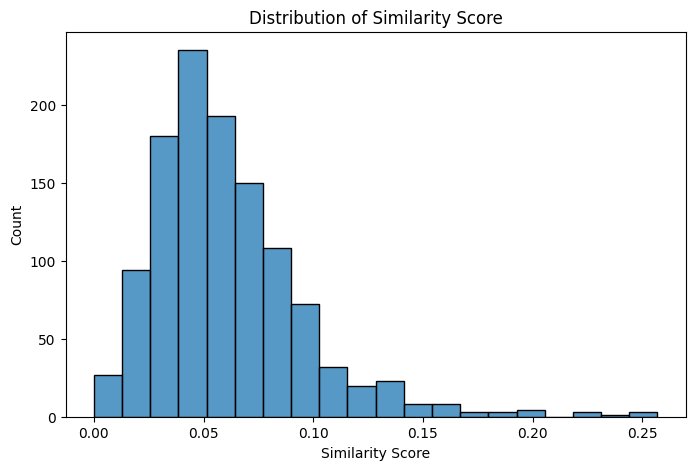

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

#Visualisasi Similarity Score
plt.figure(figsize=(8,5))

sns.histplot(
    df['similarity_score'],
    bins=20
)

plt.title('Distribution of Similarity Score')
plt.xlabel('Similarity Score')
plt.ylabel('Count')

plt.show()

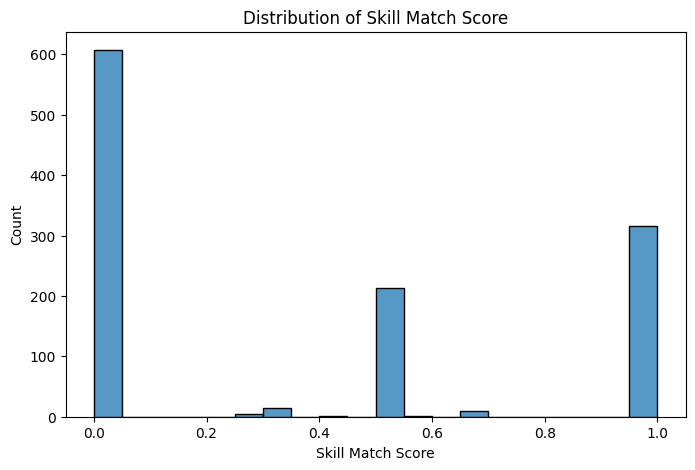

In [23]:
#Visualisasi Skill Matching
plt.figure(figsize=(8,5))

sns.histplot(
    df['skill_match_score'],
    bins=20
)

plt.title('Distribution of Skill Match Score')
plt.xlabel('Skill Match Score')
plt.ylabel('Count')

plt.show()

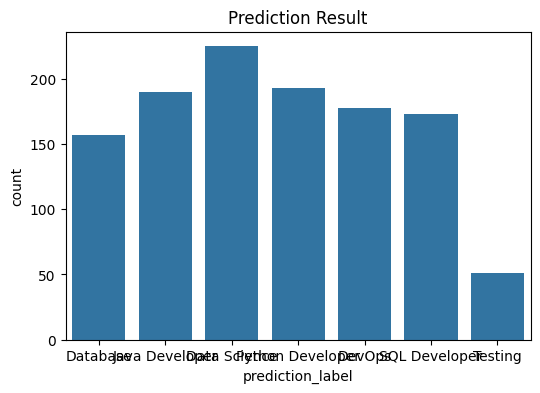

In [24]:
#Visualisasi Prediction Result
plt.figure(figsize=(6,4))

sns.countplot(
    x='prediction_label',
    data=df
)

plt.title('Prediction Result')

plt.show()

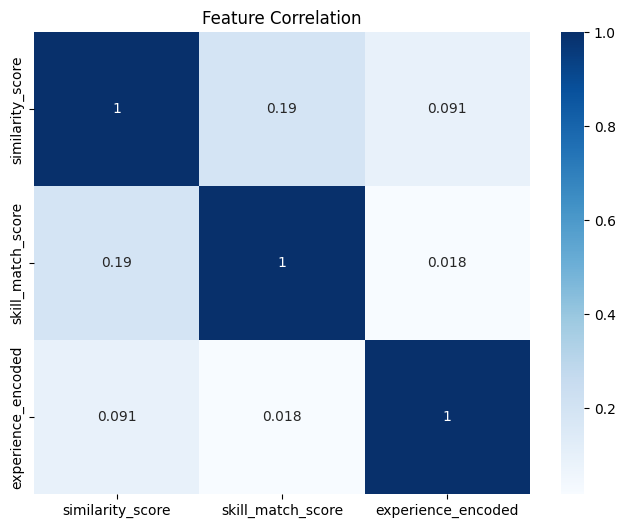

In [25]:
#Correlation Heatmap
features = [
    'similarity_score',
    'skill_match_score',
    'experience_encoded'
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[features].corr(),
    annot=True,
    cmap='Blues'
)

plt.title('Feature Correlation')

plt.show()

In [26]:
#Insight Analysis
print('Average Similarity Score:')
print(df['similarity_score'].mean())

print('\nAverage Skill Match Score:')
print(df['skill_match_score'].mean())

print('\nPrediction Distribution:')
print(df['prediction_label'].value_counts())

Average Similarity Score:
0.06084754976564898

Average Skill Match Score:
0.37375035704084547

Prediction Distribution:
prediction_label
Data Science        225
Python Developer    193
Java Developer      190
DevOps              178
SQL Developer       173
Database            157
Testing              51
Name: count, dtype: int64


In [27]:
#Menyimpan Dataset Baru
df.to_csv(
    'enhanced_processed_data.csv',
    index=False
)

print('Dataset berhasil disimpan')

Dataset berhasil disimpan
